# 03 · Execution Time Analysis

This notebook analyses execution time across languages and its relationship to energy.

**Units:** Time values are in **milliseconds (ms)** (converted from raw µs at load time).
Energy values are in **Joules (J)**.

**Key questions:**
- Which languages execute fastest?
- How does time correlate with CPU and memory energy?
- What is the Energy-Delay Product (EDP = CPU energy × time, in J·ms)?

**Methodology:** Rankings (time, EDP) and heatmaps use the **two-step mean** (equal
benchmark weight) from `results_clean_runs.csv` via `lang_means()`. Spearman correlation is
used for the energy↔time relationship (more robust than Pearson for right-skewed data),
and the paradigm comparison keeps the non-parametric Kruskal-Wallis / Mann-Whitney tests.

In [17]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))   # make the shared style module importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from itertools import combinations

import plot_style as ps
ps.apply_style()

# Canonical constants — single source: plot_style.
COL_CPU_ENERGY, COL_MEM_ENERGY = ps.COL_CPU_ENERGY, ps.COL_MEM_ENERGY
COL_TIME                       = ps.COL_TIME
COL_CPU_CARBON, COL_MEM_CARBON = ps.COL_CPU_CARBON, ps.COL_MEM_CARBON
PARADIGM        = ps.PARADIGM
PARADIGM_COLORS = ps.PARADIGM_COLORS
PARADIGM_ORDER  = ps.PARADIGM_ORDER
MEANPROPS       = ps.MEANPROPS
ALPHA           = ps.ALPHA

OUTPUTS_DIR = Path('outputs'); OUTPUTS_DIR.mkdir(exist_ok=True)

# Single source of truth: per-run rows (df) + per-cell means with EDP (df_mean).
df      = ps.load_runs()
df_mean = ps.cell_means(df)

def lang_means(cols):
    """Per-language two-step mean (equal benchmark weight) for column(s) `cols`."""
    return ps.lang_means(df_mean, cols)

print(f"Runs: {df.shape} | Cell-means: {df_mean.shape} | "
      f"{df['language'].nunique()} languages \u00d7 {df['benchmark'].nunique()} benchmarks")
df_mean.head(3)

Runs: (1280, 17) | Cell-means: (144, 16) | 18 languages × 8 benchmarks


,language,benchmark,cpu_carbon_rapl_msr_component-package_0-g,cpu_energy_rapl_msr_component-package_0-j,disk_total_read_cgroup_container-container-mb,disk_total_write_cgroup_container-container-mb,embodied_carbon_share_machine-system-g,memory_carbon_rapl_msr_component-dram_0-g,memory_energy_rapl_msr_component-dram_0-j,network_carbon_formula_global-formula-g,network_energy_formula_global-formula-j,network_power_formula_global-formula-w,network_total_cgroup_container-container-mb,phase_time_syscall_system-system-ms,paradigm,EDP
0,C,binary-trees,0.002967,31.976886,0.192512,0.0,0.001753,0.000122,1.311170,0.000000e+00,0.000000,0.0,0.000000,1221.817400,AOT,40671.925300
1,C,fannkuch-redux,0.006453,69.556996,0.000000,0.0,0.003131,0.000063,0.682479,5.714286e-07,0.005702,0.0,0.000039,2182.097714,AOT,153269.397538
2,C,fasta,0.003574,38.523294,0.000000,0.0,0.002074,0.000081,0.870375,1.666667e-06,0.018067,0.0,0.000122,1445.462222,AOT,56942.061458


## 1. Execution Time by Language

Boxplots sorted by **mean** execution time (ms), with the mean marked (▲). Log scale is used
because time spans several orders of magnitude across languages and benchmarks. The box still
shows the median/quartiles as a distribution reference.

/var/folders/42/3rphxfts3xvg8_5r8cm8ls_w0000gn/T/ipykernel_58188/4021704190.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


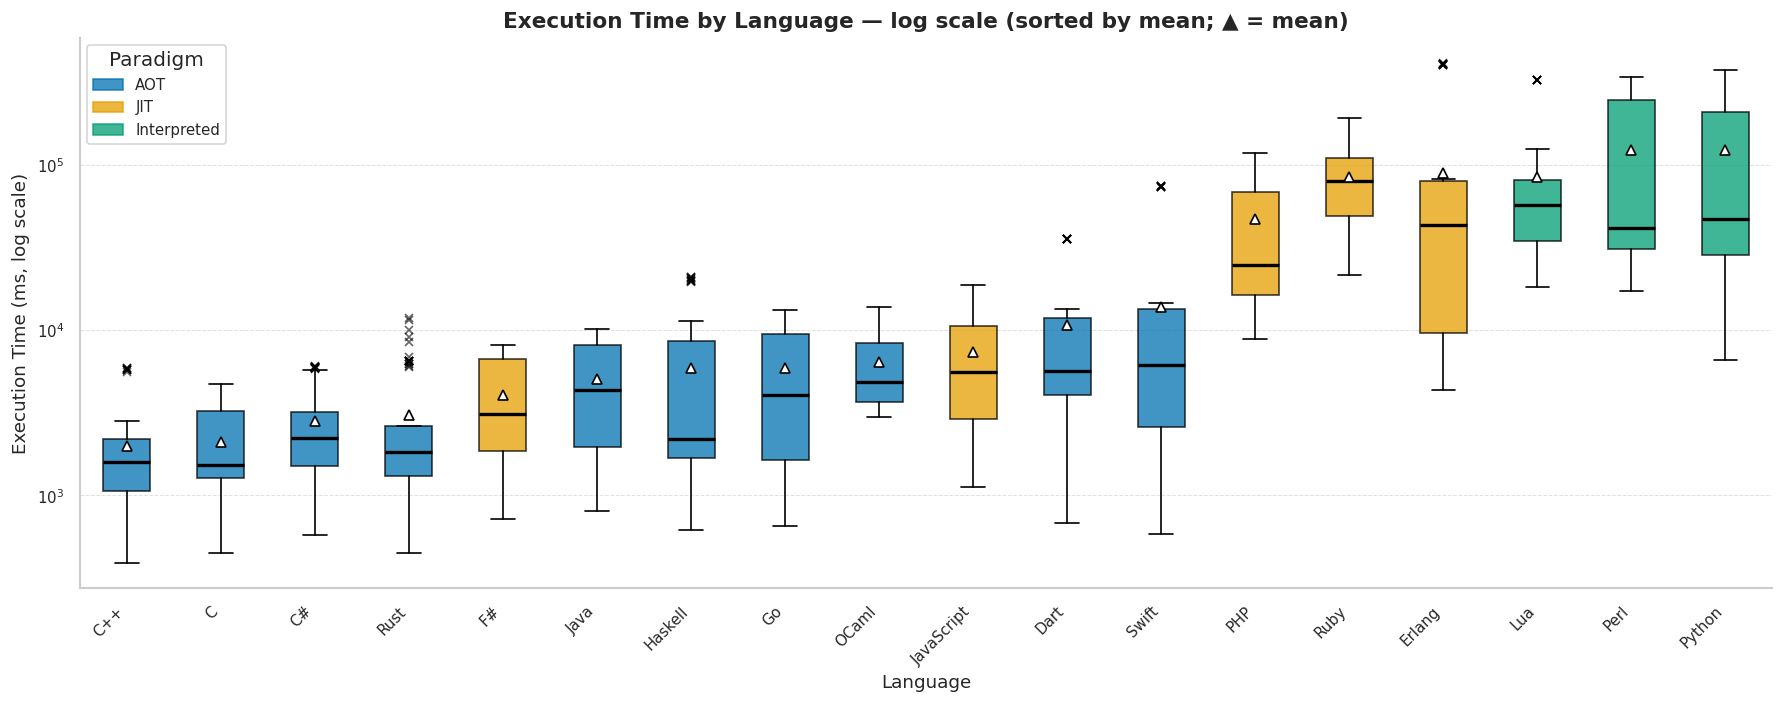

In [18]:
time_mean = lang_means(COL_TIME)
lang_order_time = time_mean.sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(15, 6))
bp = ax.boxplot(
    [df[df['language'] == lang][COL_TIME].values for lang in lang_order_time],
    labels=lang_order_time, patch_artist=True, showmeans=True, meanprops=MEANPROPS,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='x', markerfacecolor='red', markersize=5, alpha=0.6),
)
for patch, lang in zip(bp['boxes'], lang_order_time):
    patch.set_facecolor(PARADIGM_COLORS[PARADIGM[lang]])
    patch.set_alpha(0.75)

ax.set_yscale('log')
ax.set_title('Execution Time by Language — log scale (sorted by mean; ▲ = mean)', fontsize=13)
ax.set_xlabel('Language')
ax.set_ylabel('Execution Time (ms, log scale)')
legend_handles = [mpatches.Patch(color=PARADIGM_COLORS[p], label=p, alpha=0.75)
                  for p in PARADIGM_ORDER]
ax.legend(handles=legend_handles, title='Paradigm', loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
ps.save_fig(fig, '03_time_by_language')
plt.show()

> **Takeaway:** execution time spans ~3 orders of magnitude (log scale); AOT native binaries are fastest, interpreted languages slowest.

## 2. Time vs CPU Energy

Scatter plot of mean execution time (ms) vs mean CPU energy (J) per language (two-step mean).
A strong correlation is expected. The quadrants reveal interesting outliers:
- **Top-left**: fast but energy-hungry (parallel overhead?)
- **Bottom-right**: slow but energy-efficient

Spearman r(time ms, CPU energy J) = 0.9794, p = 0.0000


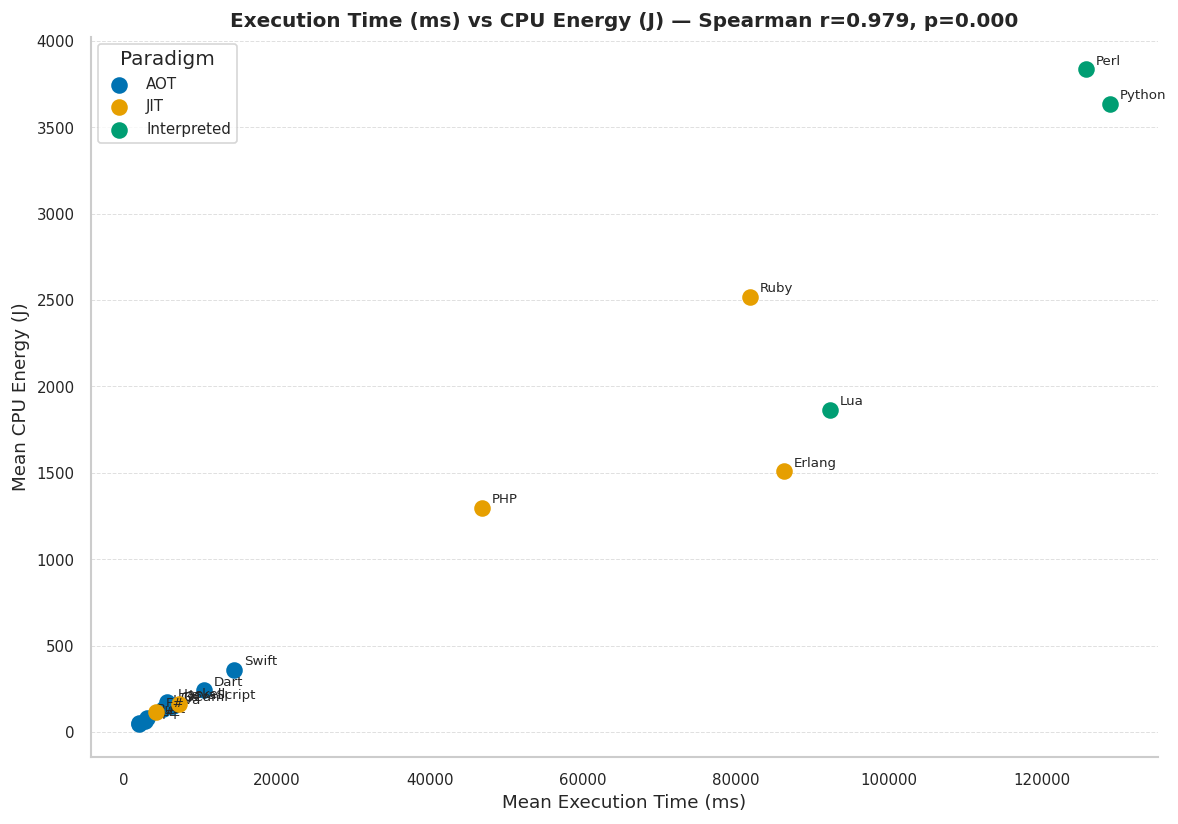

In [19]:
agg_time = df_mean.groupby('language').agg(
    time_mean  = (COL_TIME, 'mean'),
    cpu_mean   = (COL_CPU_ENERGY, 'mean'),
    mem_mean   = (COL_MEM_ENERGY, 'mean'),
    paradigm   = ('paradigm', 'first'),
).reset_index()

r, p = stats.spearmanr(agg_time['time_mean'], agg_time['cpu_mean'])
print(f"Spearman r(time ms, CPU energy J) = {r:.4f}, p = {p:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
for paradigm in PARADIGM_ORDER:
    sub = agg_time[agg_time['paradigm'] == paradigm]
    ax.scatter(sub['time_mean'], sub['cpu_mean'],
               color=PARADIGM_COLORS[paradigm], label=paradigm, s=80, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['language'],
                    (row['time_mean'], row['cpu_mean']),
                    textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Mean Execution Time (ms)')
ax.set_ylabel('Mean CPU Energy (J)')
ax.set_title(f'Execution Time (ms) vs CPU Energy (J) — Spearman r={r:.3f}, p={p:.3f}', fontsize=12)
ax.legend(title='Paradigm')
plt.tight_layout()
ps.save_fig(fig, '03_time_vs_cpu_energy')
plt.show()

> **Takeaway:** execution time and CPU energy are strongly rank-correlated (Spearman printed above) — slower languages are also more energy-hungry.

## 3. Time vs Memory Energy

Same analysis for Memory Energy (J). Memory energy tends to correlate less tightly with
time because DRAM power draw depends more on allocation patterns than execution duration.

Spearman r(time ms, Memory energy J) = 0.9649, p = 0.0000


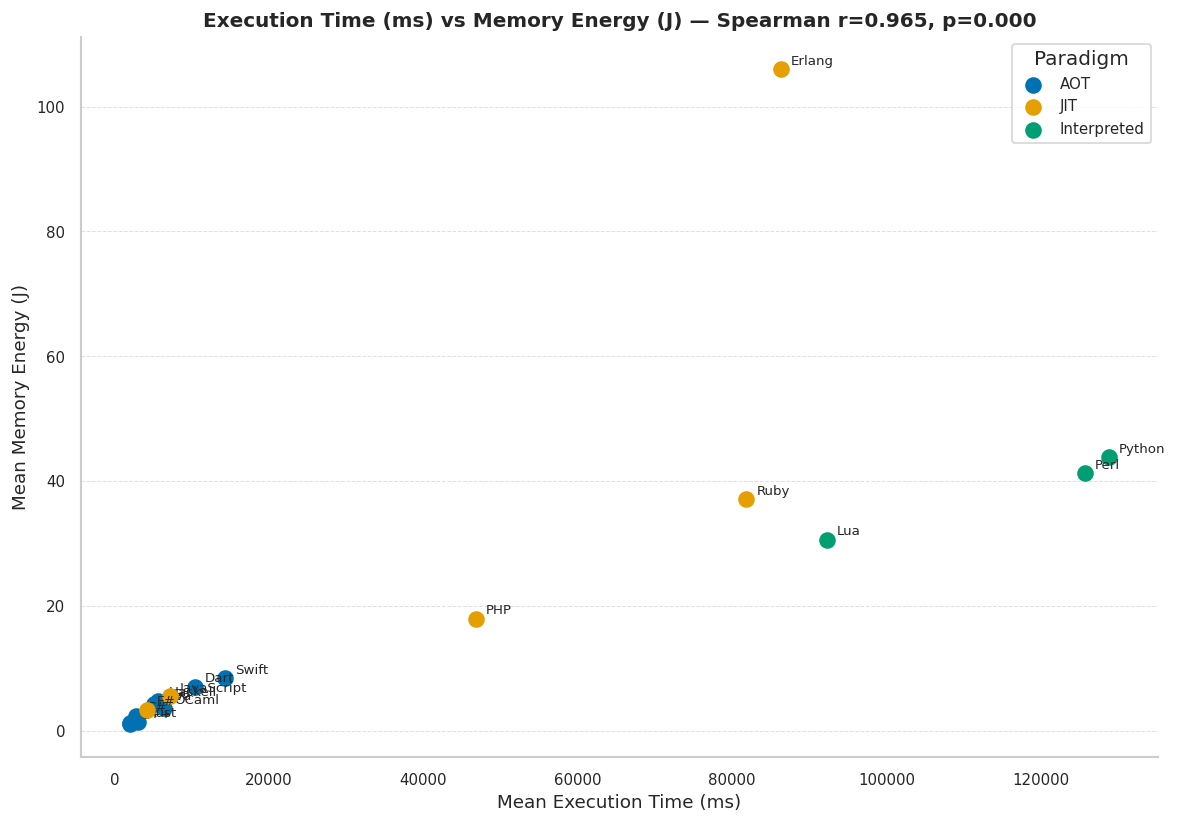

In [20]:
r_mem, p_mem = stats.spearmanr(agg_time['time_mean'], agg_time['mem_mean'])
print(f"Spearman r(time ms, Memory energy J) = {r_mem:.4f}, p = {p_mem:.4f}")

fig, ax = plt.subplots(figsize=(10, 7))
for paradigm in PARADIGM_ORDER:
    sub = agg_time[agg_time['paradigm'] == paradigm]
    ax.scatter(sub['time_mean'], sub['mem_mean'],
               color=PARADIGM_COLORS[paradigm], label=paradigm, s=80, zorder=3)
    for _, row in sub.iterrows():
        ax.annotate(row['language'],
                    (row['time_mean'], row['mem_mean']),
                    textcoords='offset points', xytext=(6, 3), fontsize=8)

ax.set_xlabel('Mean Execution Time (ms)')
ax.set_ylabel('Mean Memory Energy (J)')
ax.set_title(f'Execution Time (ms) vs Memory Energy (J) — Spearman r={r_mem:.3f}, p={p_mem:.3f}', fontsize=12)
ax.legend(title='Paradigm')
plt.tight_layout()
ps.save_fig(fig, '03_time_vs_mem_energy')
plt.show()

> **Takeaway:** memory energy correlates with time more weakly than CPU energy, since DRAM draw depends on allocation patterns more than wall-clock duration.

## 4. Paradigm Speed Comparison

Kruskal-Wallis test on execution time across paradigm groups, followed by pairwise
Mann-Whitney U tests with Bonferroni correction.

In [21]:
def rank_biserial(x, y):
    u, _ = stats.mannwhitneyu(x, y, alternative='two-sided')
    return 1 - (2 * u) / (len(x) * len(y))

groups = {p: df[df['paradigm'] == p][COL_TIME].values for p in PARADIGM_ORDER}
kw_stat, kw_p = stats.kruskal(*groups.values())
n_pairs = len(PARADIGM_ORDER) * (len(PARADIGM_ORDER) - 1) // 2

print(f"Kruskal-Wallis (Execution Time, ms): H={kw_stat:.3f}, p={kw_p:.4f}")
print("SIGNIFICANT" if kw_p < ALPHA else "Not significant")

if kw_p < ALPHA:
    print(f"\nPost-hoc (Bonferroni α={ALPHA/n_pairs:.4f}):")
    for p1, p2 in combinations(PARADIGM_ORDER, 2):
        u, p = stats.mannwhitneyu(groups[p1], groups[p2], alternative='two-sided')
        p_adj = min(p * n_pairs, 1.0)
        r = rank_biserial(groups[p1], groups[p2])
        sig = "✓" if p_adj < ALPHA else "✗"
        print(f"  {sig} {p1} vs {p2}: p_adj={p_adj:.4f}, r={r:.3f}")

Kruskal-Wallis (Execution Time, ms): H=574.059, p=0.0000
SIGNIFICANT

Post-hoc (Bonferroni α=0.0167):
  ✓ AOT vs JIT: p_adj=0.0000, r=0.600
  ✓ AOT vs Interpreted: p_adj=0.0000, r=0.954
  ✓ JIT vs Interpreted: p_adj=0.0000, r=0.495


## 5. Energy-Delay Product (EDP)

**EDP = (CPU Energy + Memory Energy) (J) × Execution Time (ms)** — unit: **J·ms**

EDP is a standard hardware metric penalising both slow and energy-hungry implementations.
Including memory energy captures the full energy cost of execution. Lower EDP is better.

In [ ]:
# EDP per cell = (CPU + Mem energy) × time, computed in the load cell on df_mean.
# Two-step mean: average the per-benchmark EDP with equal benchmark weight.
edp_rank = (lang_means('EDP')
              .sort_values()
              .reset_index())
edp_rank.columns = ['language', 'EDP_mean_Jms']
edp_rank['paradigm'] = edp_rank['language'].map(PARADIGM)

print("EDP Ranking — lower is better (unit: J·ms):")
print(edp_rank[['language', 'paradigm', 'EDP_mean_Jms']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 7))
colors = [PARADIGM_COLORS[p] for p in edp_rank['paradigm']]
bars = ax.barh(edp_rank['language'], edp_rank['EDP_mean_Jms'], color=colors, alpha=0.85, edgecolor='white')

# value label at the end of each bar
x_max = edp_rank['EDP_mean_Jms'].max()
for bar, val in zip(bars, edp_rank['EDP_mean_Jms']):
    ax.text(bar.get_width() + x_max * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='left', fontsize=8, color='#333333')
ax.set_xlim(0, x_max * 1.22)

ax.set_title('Energy-Delay Product Ranking — (CPU + Mem) Energy × Time (J·ms, mean)', fontsize=12)
ax.set_xlabel('EDP (J·ms)')
ax.set_ylabel('Language')
ax.invert_yaxis()
legend_handles = [mpatches.Patch(color=PARADIGM_COLORS[p], label=p, alpha=0.85)
                  for p in PARADIGM_ORDER]
ax.legend(handles=legend_handles, title='Paradigm', loc='lower right')
plt.tight_layout()
ps.save_fig(fig, '03_edp_ranking')
plt.show()

> **Takeaway:** the EDP ranking (penalising both slow and energy-hungry runs) is led by the AOT compilers; Erlang's long regex-redux run pushes it to the bottom.

## 6. Benchmark-Level Time Heatmap

Mean execution time (ms) for each language × benchmark cell (the per-cell means stored in
`results_clean_runs.csv`). Reveals which benchmarks are the slowest and which languages suffer
most on specific workloads.

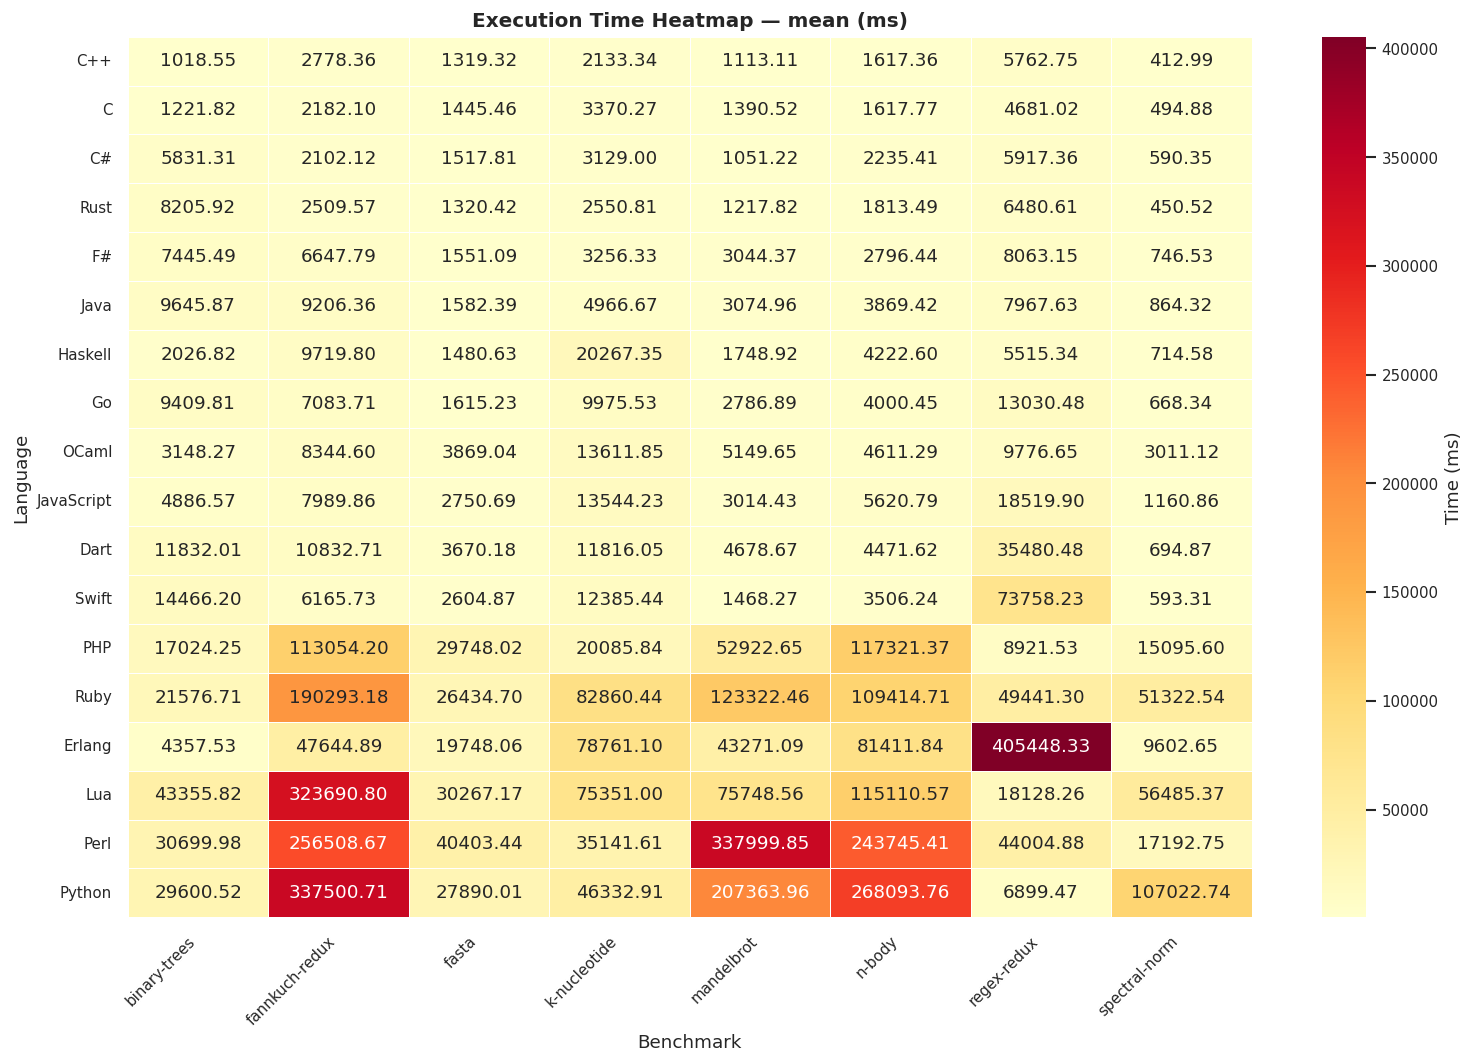

In [23]:
pivot_time = df_mean.pivot(index='language', columns='benchmark', values=COL_TIME)
lang_sort = lang_means(COL_TIME).sort_values().index
pivot_time = pivot_time.loc[lang_sort]

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Time (ms)'})
ax.set_title('Execution Time Heatmap — mean (ms)', fontsize=12)
ax.set_xlabel('Benchmark')
ax.set_ylabel('Language')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
ps.save_fig(fig, '03_time_heatmap_benchmark')
plt.show()

> **Takeaway:** regex-redux and k-nucleotide are the slowest workloads, and the interpreted languages pay the largest time penalty on them.